Using device: cpu
-> 입력 이미지 텐서 Shape: torch.Size([64, 1, 28, 28])
-> 정답 레이블 텐서 Shape: torch.Size([64])

--- 모델 학습 및 검증 시작 ---
Epoch [1/5] | Train Loss: 0.2484, Train Acc: 92.42% | Val Loss: 0.1299, Val Acc: 96.01%
Epoch [2/5] | Train Loss: 0.1033, Train Acc: 96.76% | Val Loss: 0.1166, Val Acc: 96.57%
Epoch [3/5] | Train Loss: 0.0708, Train Acc: 97.73% | Val Loss: 0.0968, Val Acc: 97.29%
Epoch [4/5] | Train Loss: 0.0513, Train Acc: 98.28% | Val Loss: 0.0950, Val Acc: 97.27%
Epoch [5/5] | Train Loss: 0.0412, Train Acc: 98.60% | Val Loss: 0.0906, Val Acc: 97.47%


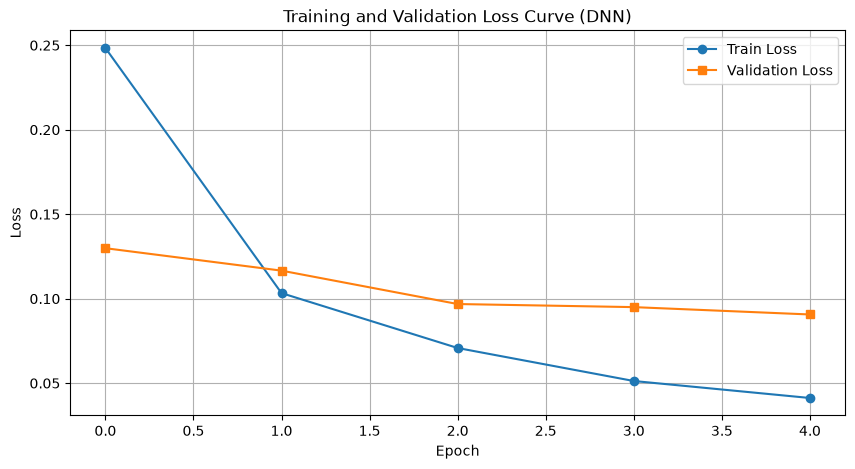


[Test 결과] 최종 테스트 정확도(Accuracy): 97.61%


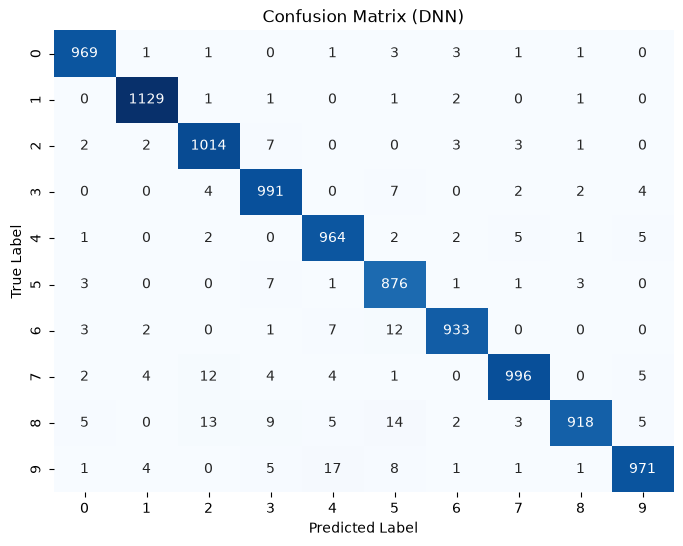


[오분류 분석] 테스트 데이터 중 틀린 이미지 개수: 239개


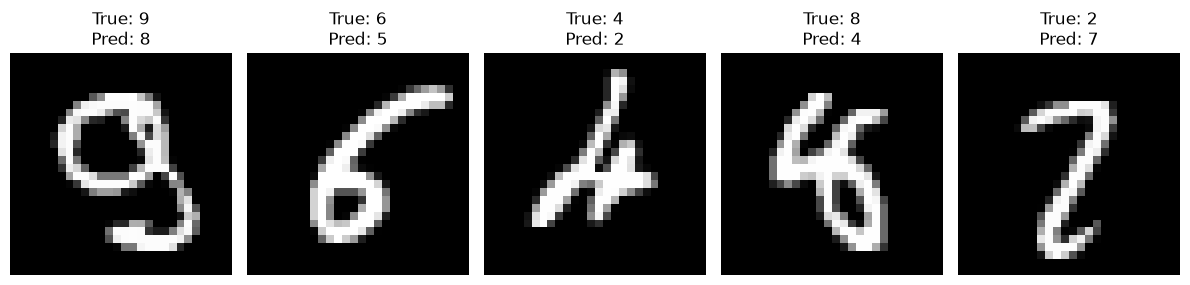


[모델 저장 완료] 학습된 DNN 모델 가중치가 'mnist_dnn_model.pth'로 저장되었습니다.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# ==========================================
# 1. 학습 장치(Device) 설정
# ==========================================
# PyTorch 연산을 수행할 하드웨어 장치를 선택합니다.
# CUDA(NVIDIA GPU) 가속이 가능하면 'cuda', 그렇지 않으면 기본 'cpu'를 사용합니다.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")




In [ ]:
# ==========================================
# 2. 전처리 정의 및 MNIST Dataset 로드
# ==========================================
# 이미지 데이터에 적용할 전처리 연산(Transform) 연속 과정을 파이프라인으로 정의합니다.
transform = transforms.Compose([
    # 1) ToTensor(): PIL 이미지(또는 NumPy 배열)를 PyTorch Tensor 형태로 변환합니다.
    #    - 형상 변환: (H, W, C) -> (C, H, W) (채널이 가장 앞으로 이동)
    #    - 스케일링: [0, 255] 범위를 [0.0, 1.0] 실수 범위로 자동 정규화합니다.
    transforms.ToTensor(),                          
    
    # 2) Normalize((mean,), (std,)): 입력 텐서를 표준화(Z-score Normalization)합니다.
    #    - 공식: x_normalized = (x - mean) / std
    #    - 0.1307, 0.3081은 MNIST 데이터셋 전체 픽셀의 사전 계산된 평균과 표준편차입니다.
    #    - 목적: 데이터 분포의 픽셀값을 0 중심으로 정렬하여 경사하강법 학습 속도 및 안정성을 향상시킵니다.
    transforms.Normalize((0.1307,), (0.3081,))      
])

# 학습용(Train) MNIST 데이터셋 다운로드 및 객체 생성
full_train_dataset = torchvision.datasets.MNIST(
    root='./data',          # 데이터가 저장될 로컬 디렉토리 경로
    train=True,             # True: 60,000개의 학습 데이터셋 로드
    download=True,          # 지정된 경로에 데이터가 없으면 자동으로 인터넷에서 다운로드
    transform=transform     # 위에서 정의한 전처리 함수 적용
)

# 테스트용(Test) MNIST 데이터셋 다운로드 및 객체 생성
test_dataset = torchvision.datasets.MNIST(
    root='./data',          # 동일한 디렉토리 참조
    train=False,            # False: 10,000개의 평가/테스트 데이터셋 로드
    download=True, 
    transform=transform
)


In [2]:
print(f'full_train_dataset : {dir(full_train_dataset)}')

full_train_dataset : ['__add__', '__annotations__', '__class__', '__class_getitem__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__orig_bases__', '__parameters__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_check_exists', '_check_legacy_exist', '_format_transform_repr', '_load_data', '_load_legacy_data', '_repr_indent', 'class_to_idx', 'classes', 'data', 'download', 'extra_repr', 'mirrors', 'processed_folder', 'raw_folder', 'resources', 'root', 'target_transform', 'targets', 'test_data', 'test_file', 'test_labels', 'train', 'train_data', 'train_labels', 'training_file', 'transform', 'transforms']


In [3]:
# ==========================================
# 3. 데이터셋 분할 및 DataLoader 구성
# ==========================================
# 모델의 과적합(Overfitting)을 모니터링하기 위해 전체 60,000개 학습 데이터를 
# 학습용(50,000개)과 검증용(10,000개)으로 무작위 분할합니다.
train_size = 50000
val_size = 10000
train_dataset, val_dataset = torch.utils.data.random_split(
    full_train_dataset, [train_size, val_size]
)

# DataLoader: 생성된 Dataset을 받아 데이터를 효율적으로 미니배치(Mini-batch)로 묶어 제공하는 반복자(Iterator)
# - batch_size: 한 번의 가중치 업데이트에 사용할 샘플 개수
# - shuffle=True: 에폭(Epoch)마다 데이터 순서를 무작위로 섞어 특정 순서 패턴에 편향되는 것을 방지
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
val_loader = torch.utils.data.DataLoader(dataset=val_dataset, batch_size=1000, shuffle=False)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)

# 샘플 데이터 추출을 통해 텐서 구조 확인
examples = enumerate(train_loader)
batch_idx, (sample_data, sample_targets) = next(examples)
# sample_data.shape  -> torch.Size([64, 1, 28, 28]) : [배치크기, 채널(흑백1), 높이, 너비]
# sample_targets.shape -> torch.Size([64]) : 배치 내 64개 이미지에 대한 정답 숫자 라벨 (0~9)
print(f"-> 입력 이미지 텐서 Shape: {sample_data.shape}")  
print(f"-> 정답 레이블 텐서 Shape: {sample_targets.shape}") 


-> 입력 이미지 텐서 Shape: torch.Size([64, 1, 28, 28])
-> 정답 레이블 텐서 Shape: torch.Size([64])


In [ ]:
# ==========================================
# 4. DNN 모델 구현 (Fully Connected Layers 구성)
# ==========================================
# PyTorch의 모든 신경망 모듈은 nn.Module을 상속받아 구현합니다.
class DNN(nn.Module):
    def __init__(self):
        super(DNN, self).__init__() # 부모 클래스(nn.Module)의 초기화 메서드 호출
        
        # 1차 완전연결층(Linear Layer): 28x28 이미지 픽셀 784개를 입력받아 256개 특성 노드로 변환
        # 수식: Y = X * W^T + b  (W shape: [256, 784], b shape: [256])
        self.fc1 = nn.Linear(28 * 28, 256)
        
        # 2차 완전연결층: 256개 특성을 받아서 128개 차원으로 더욱 압축/추상화
        self.fc2 = nn.Linear(256, 128)
        
        # 출력층(Output Layer): 128개 특성을 받아서 최종 10개 클래스(숫자 0~9)에 대한 Logit 점수 산출
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        """
        순전파(Forward Pass): 입력 데이터를 신경망 연산 순서에 따라 흘려보내는 메서드
        """
        # x의 차원: [64, 1, 28, 28] -> 2D 이미지를 1D 벡터로 평탄화(Flatten)
        # -1은 배치 사이즈(64)를 자동 유지하도록 지정하는 의미입니다. 결과 Shape: [64, 784]
        x = x.view(-1, 28 * 28)
        
        # fc1 선형 연산 수행 후, 비선형 활성화 함수 ReLU 적용
        # ReLU(x) = max(0, x): 음수 값은 0으로 바꾸고 양수 값은 그대로 유지
        x = F.relu(self.fc1(x))
        
        # fc2 선형 연산 수행 후, ReLU 적용
        x = F.relu(self.fc2(x))
        
        # final layer: Softmax를 거치지 않은 원시 점수(Logits) 상태로 출력
        # PyTorch의 CrossEntropyLoss 내부에 Softmax가 내장되어 있어 모델 마지막에는 적용하지 않음
        x = self.fc3(x)
        return x


In [5]:

# 모델 객체 생성 후 지정된 계산 장치(GPU 또는 CPU)로 이동 (가중치 텐서들이 지정 장치에 할당됨)
model = DNN().to(device)

In [7]:
# ==========================================
# 5. Loss Function 및 Optimizer 구성
# ==========================================
# 손실 함수(Loss Function) 설정: 다중 클래스 분류용 교차 엔트로피 손실 함수 사용
# - 내부적으로 Softmax 계산과 NLLLoss(Negative Log Likelihood Loss) 연산을 결합하여 처리함
criterion = nn.CrossEntropyLoss()

# 최적화 알고리즘(Optimizer) 설정: Adam (Adaptive Moment Estimation) 사용
# - model.parameters(): 최적화할 신경망의 가중치(W) 및 편향(b) 매개변수 전달
# - lr=0.001: 학습률(Learning Rate), 매 스텝마다 가중치를 업데이트할 크기 조절
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [8]:
print(dir(model.parameters() ))

['__class__', '__del__', '__delattr__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__lt__', '__name__', '__ne__', '__new__', '__next__', '__qualname__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', 'close', 'gi_code', 'gi_frame', 'gi_running', 'gi_suspended', 'gi_yieldfrom', 'send', 'throw']


In [ ]:
# ==========================================
# 6. Training Loop 및 Validation 구현
# ==========================================
num_epochs = 5                  # 전체 데이터셋을 반복 학습할 총 횟수
train_losses, val_losses = [], []      # 에폭별 손실값 기록용 리스트
train_accuracies, val_accuracies = [], []  # 에폭별 정확도 기록용 리스트

print("\n--- 모델 학습 및 검증 시작 ---")
for epoch in range(num_epochs):
    # ------------------------------------------------------------------
    # 6-1. 학습 모드 (Training Phase)
    # ------------------------------------------------------------------
    model.train()  # 모델을 학습 모드로 설정 (Dropout, BatchNorm 동작 방식을 학습 모드로 전환)
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    # 미니배치 단위로 train_loader에서 데이터를 하나씩 꺼내와 학습 진행
    for images, labels in train_loader:
        # 배치 데이터를 설정된 장치(GPU/CPU)로 전송
        images, labels = images.to(device), labels.to(device)
        
        # [핵심 Step 1] 이전 배치에서 계산되어 누적된 경사도(Gradient) 버퍼 초기화
        # 파이토치는 기본적으로 그래디언트를 누적(add)하므로 배치마다 0으로 비워주어야 함
        optimizer.zero_grad()
        
        # [핵심 Step 2] 순전파(Forward Pass): 모델 예측 수행 (Logits 출력: [64, 10])
        outputs = model(images)
        
        # [핵심 Step 3] 손실(Loss) 계산: 예측값과 정답 라벨 비교
        loss = criterion(outputs, labels)
        
        # [핵심 Step 4] 역전파(Backward Pass): 손실에 대한 각 매개변수(W, b)의 미분값(기울기) 계산
        # 자동 미분 엔진(Autograd)이 연산 그래프를 거슬러 올라가며 미분 수행
        loss.backward()  
        
        # [핵심 Step 5] 가중치 업데이트: 계산된 기울기 방향으로 최적화 알고리즘(Adam)을 적용해 W, b 갱신
        optimizer.step()
        
        # 손실값 및 정확도 계산을 위한 배치 통계 누적
        # loss.item()은 단일 손실 스칼라값, images.size(0)은 해당 배치의 데이터 개수(예: 64)
        running_loss += loss.item() * images.size(0)
        
        # torch.max(outputs.data, 1): 1번 차원(클래스 차원 10개)에서 가장 높은 점수(확률)를 가진 클래스와 인덱스를 반환
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item() # 맞춘 개수 누적
        
    # Epoch별 평균 Train 손실 및 정확도 산출
    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = 100 * correct_train / total_train  
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    
    # ------------------------------------------------------------------
    # 6-2. 검증 모드 (Validation Phase)
    # ------------------------------------------------------------------
    model.eval()  # 모델을 평가 모드로 전환 (Dropout 비활성화, BatchNorm 평가 모드)
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    # torch.no_grad(): 검증 과정에서는 그래디언트 계산(역전파)을 위한 메모리 그래프 생성을 중단하여
    # 메모리 사용량을 줄이고 평가 연산 속도를 획기적으로 향상시킴
    with torch.no_grad():  
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    # Epoch별 평균 Validation 손실 및 정확도 산출
    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = 100 * correct_val / total_val  
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%")


# ==========================================
# 7. Loss 시각화
# ==========================================
# 학습 진행에 따른 학습 손실(Train Loss)과 검증 손실(Validation Loss) 추이를 시각화합니다.
# 두 커브를 비교하여 과적합(Overfitting) 발생 여부를 직관적으로 진단할 수 있습니다.
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', marker='o')      # Train 손실 동향 (동그라미 마커)
plt.plot(val_losses, label='Validation Loss', marker='s')  # Val 손실 동향 (네모 마커)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve (DNN)')
plt.legend()
plt.grid(True)
plt.savefig('dnn_loss_curve.png') # 그래프를 파일로 저장
plt.show()


# ==========================================
# 8. Test 구현 및 Accuracy 계산
# ==========================================
# 단 한 번도 학습 및 검증에 관여하지 않은 완전히 독립된 Test 데이터셋으로 최종 모델의 일반화 성능 평가
model.eval()
correct_test = 0
total_test = 0
all_preds = []    # Confusion Matrix 생성을 위한 예측 라벨 저장 리스트
all_targets = []  # Confusion Matrix 생성을 위한 실제 정답 라벨 저장 리스트

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        
        # 예측값 산출 (0~9 중 가장 높은 스코어를 기록한 인덱스 선택)
        _, predicted = torch.max(outputs.data, 1)
        
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()  
        
        # GPU 텐서를 CPU로 이동시킨 후, NumPy 배열로 변환하여 저장 (Scikit-Learn 연산용)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

test_accuracy = 100 * correct_test / total_test
print(f"\n[Test 결과] 최종 테스트 정확도(Accuracy): {test_accuracy:.2f}%")


# ==========================================
# 9. Confusion Matrix 작성 및 시각화
# ==========================================
# 혼동 행렬(Confusion Matrix): 모델이 어떤 클래스를 어떤 클래스로 잘못 예측했는지 세부 분해
# 행(Row): 실제 정답 라벨 (True Label)
# 열(Column): 모델 예측 라벨 (Predicted Label)
conf_matrix = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(8, 6))
# annot=True: 셀 내부에 수치 표기, fmt='d': 정수 형식으로 표기, cmap='Blues': 파란색 계열 히트맵
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (DNN)')
plt.savefig('dnn_confusion_matrix.png')
plt.show()


# ==========================================
# 10. 오분류 이미지 분석 (Misclassified Image Analysis)
# ==========================================
# 모델이 잘못 판단한 샘플들을 추출하여 원인을 직접 visual하게 파악하는 디버깅 단계
all_preds_np = np.array(all_preds)
all_targets_np = np.array(all_targets)

# np.where: 조건(예측값 != 정답)을 만족하는 샘플의 인덱스 배열 반환
misclassified_idx = np.where(all_preds_np != all_targets_np)[0]

print(f"\n[오분류 분석] 테스트 데이터 중 틀린 이미지 개수: {len(misclassified_idx)}개")

plt.figure(figsize=(12, 5))
# 잘못 예측된 데이터 중 상위 5개를 가져와 시각화
for i, idx in enumerate(misclassified_idx[:5]):  
    image, true_label = test_dataset[idx]
    pred_label = all_preds_np[idx]
    
    plt.subplot(1, 5, i + 1)
    
    # [역정규화(Un-normalization) 연산]
    # 이전 전처리 과정 공식: normalized = (original - mean) / std
    # 이미지로 복원하는 공식: original = (normalized * std) + mean
    # image.squeeze(): [1, 28, 28] 차원의 텐서에서 크기가 1인 채널 차원을 제거하여 [28, 28]로 만듦
    img_np = image.squeeze().numpy() * 0.3081 + 0.1307
    
    plt.imshow(img_np, cmap='gray') # 흑백 이미지 출력
    plt.title(f"True: {true_label}\nPred: {pred_label}") # 정답과 모델이 오인한 라벨 표시
    plt.axis('off') # 축 눈금 지우기

plt.tight_layout()
plt.savefig('dnn_misclassified_images.png')
plt.show()


# ==========================================
# 11. 모델 저장 (Model Saving)
# ==========================================
# model.state_dict(): 모델 내의 학습 가능한 모든 레이어 가중치(W)와 편향(b)이 들어있는 Python Dictionary
# pth(또나 pt) 확장자로 저장하여 나중에 재학습 없이 똑같이 로드하여 추론에 활용 가능
torch.save(model.state_dict(), 'mnist_dnn_model.pth')
print("\n[모델 저장 완료] 학습된 DNN 모델 가중치가 'mnist_dnn_model.pth'로 저장되었습니다.")